<a href="https://colab.research.google.com/github/gflamiano/SJU-CSC-672-ML/blob/main/HW3/churn_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 3


### Task 1: Load the dataset into a Pandas DataFrame.

In [27]:
import pandas as pd

DATA_URL = 'https://raw.githubusercontent.com/gflamiano/SJU-CSC-672-ML/refs/heads/main/HW3/WA_Fn-UseC_-Telco-Customer-Churn.csv'

df = pd.read_csv(DATA_URL)

### Task 2: Use structural inspection methods (`head()`, `info()`, `describe()`) to analyze features such as `tenure`, `MonthlyCharges`, `TotalCharges`, `Contract`, and `PaymentMethod`.

In [28]:
# Display the dimensions of the dataset
print(f"Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns\n")

# Display the first 5 rows
display(df.head())

# Print concise summary of columns, non-null counts, and data types
print("\nDataset Information:")
df.info()

print("\nDescribe Dataset:")
df.describe()

Dataset Shape: 7043 rows, 21 columns



,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes



Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  70

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [29]:
feature_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'Contract', 'PaymentMethod']

print("\nHead of selected columns:")
print(df[feature_cols].head())

print("\nInfo (dtypes & non-null counts) for selected columns:")
print(df[feature_cols].info())

print("\nDescribe numeric selected columns:")
print(df[['tenure', 'MonthlyCharges']].describe())

print("\nValue counts for categorical selected columns:")
print("\nContract:")
print(df['Contract'].value_counts())

print("\nPaymentMethod:")
print(df['PaymentMethod'].value_counts())


Head of selected columns:
   tenure  MonthlyCharges TotalCharges        Contract  \
0       1           29.85        29.85  Month-to-month   
1      34           56.95       1889.5        One year   
2       2           53.85       108.15  Month-to-month   
3      45           42.30      1840.75        One year   
4       2           70.70       151.65  Month-to-month   

               PaymentMethod  
0           Electronic check  
1               Mailed check  
2               Mailed check  
3  Bank transfer (automatic)  
4           Electronic check  

Info (dtypes & non-null counts) for selected columns:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   tenure          7043 non-null   int64  
 1   MonthlyCharges  7043 non-null   float64
 2   TotalCharges    7043 non-null   object 
 3   Contract        7043 non-null   object 
 4   Pa

### Task 3: Drop any non-informative identifiers (such as `customerID`).

In [30]:
df = df.drop(columns=['customerID'])

print("Shape after dropping customerID:", df.shape)
print("\nRemaining columns:")
print(df.columns.tolist())

Shape after dropping customerID: (7043, 20)

Remaining columns:
['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


### Task 4: Quantify any missing or implicit missing values across the columns (handling whitespace strings in `TotalCharges`) and implement a structured imputation strategy using Scikit-Learn's `SimpleImputer`.

In [31]:
from sklearn.impute import SimpleImputer
import numpy as np

print("Standard missing values per column (before fix):")
print(df.isna().sum())

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

print("\nMissing values per column (after converting TotalCharges to numeric):")
print(df.isna().sum())

print(f"\nTotal missing TotalCharges values: {df['TotalCharges'].isna().sum()}")
print(f"Percent of rows affected: {df['TotalCharges'].isna().mean() * 100:.2f}%")

numeric_imputer = SimpleImputer(strategy='median')
df['TotalCharges'] = numeric_imputer.fit_transform(df[['TotalCharges']])

print("\nMissing values after imputation:")
print(df.isna().sum())

print(f"\nImputed value used for TotalCharges (median): {numeric_imputer.statistics_[0]:.2f}")

Standard missing values per column (before fix):
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Missing values per column (after converting TotalCharges to numeric):
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges 

### Task 5: Isolate numerical and categorical features, then build a Scikit-Learn `ColumnTransformer` and `Pipeline` that applies appropriate scaling (`StandardScaler` or `MinMaxScaler`) to numerical columns and encoding (`OneHotEncoder`) to categorical columns.

In [32]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder

X = df.drop(columns=['Churn'])
y = df['Churn']

numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()

print("Numerical columns:", numerical_cols)
print("Categorical columns:", categorical_cols)

preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numerical_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
])

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor)
])

X_transformed = pipeline.fit_transform(X)
print("Transformed shape:", X_transformed.shape)

Numerical columns: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
Categorical columns: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
Transformed shape: (7043, 45)


### Task 6: Append an `SGDClassifier` configured with `loss='log_loss'`: to the end of your pipeline to perform logistic regression and enable probability estimation.

In [33]:
from sklearn.linear_model import SGDClassifier

clf = SGDClassifier(loss='log_loss', random_state=42)

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', clf)
])

print(pipeline)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['SeniorCitizen', 'tenure',
                                                   'MonthlyCharges',
                                                   'TotalCharges']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['gender', 'Partner',
                                                   'Dependents', 'PhoneService',
                                                   'MultipleLines',
                                                   'InternetService',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtection',
                               

### Task 7: Split your dataset into training and test sets using 3 different train/test split ratios (for example, 80/20, 70/30, and 60/40), **fit** your complete pipeline on each configuration, and **evaluate** performance using a confusion matrix, classification report, and ROC-AUC curve. Report on any performance differences detected across the various splitting ratios.


--- Test size: 0.2 ---
Confusion Matrix:
[[940  95]
 [208 166]]

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.91      0.86      1035
           1       0.64      0.44      0.52       374

    accuracy                           0.78      1409
   macro avg       0.73      0.68      0.69      1409
weighted avg       0.77      0.78      0.77      1409

ROC-AUC: 0.8296

--- Test size: 0.3 ---
Confusion Matrix:
[[1388  164]
 [ 259  302]]

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.89      0.87      1552
           1       0.65      0.54      0.59       561

    accuracy                           0.80      2113
   macro avg       0.75      0.72      0.73      2113
weighted avg       0.79      0.80      0.79      2113

ROC-AUC: 0.8420

--- Test size: 0.4 ---
Confusion Matrix:
[[1763  307]
 [ 291  457]]

Classification Report:
              precision    recall  f1-s

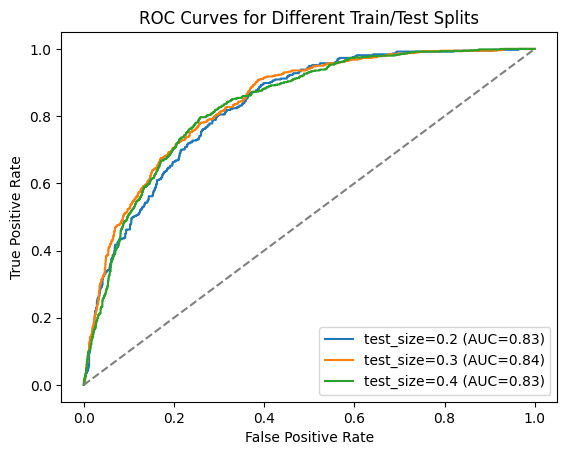

In [34]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve
import matplotlib.pyplot as plt


y_binary = y.map({'Yes': 1, 'No': 0})
split_ratios = [0.2, 0.3, 0.4]

for test_size in split_ratios:
    print(f"\n--- Test size: {test_size} ---")

    X_train, X_test, y_train, y_test = train_test_split(
        X, y_binary, test_size=test_size, random_state=42, stratify=y_binary
    )

    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    y_proba = pipeline.predict_proba(X_test)[:, 1]

    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    auc = roc_auc_score(y_test, y_proba)
    print(f"ROC-AUC: {auc:.4f}")

    fpr, tpr, _ = roc_curve(y_test, y_proba)
    plt.plot(fpr, tpr, label=f"test_size={test_size} (AUC={auc:.2f})")

plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for Different Train/Test Splits')
plt.legend()
plt.show()

### Task 8: Generate a 2D decision boundary visualization or inspect model feature coefficients to interpret how the model separates churning customers from retained customers.

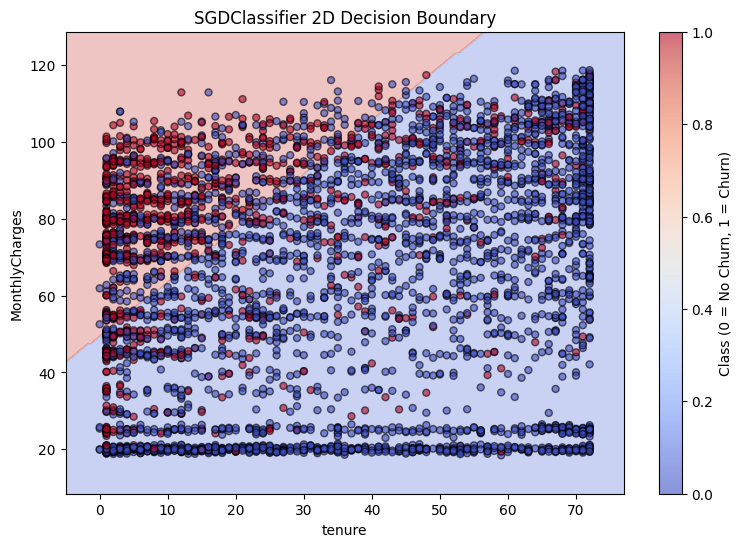

In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import SGDClassifier

# Select two prominent numerical features for 2D visualization
feat_1 = 'tenure'
feat_2 = 'MonthlyCharges'

X_2d = X_train[[feat_1, feat_2]].copy()

# Build a pipeline for these two features
clf_2d = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('classifier', SGDClassifier(loss='log_loss', max_iter=1000, random_state=42))
])

# Train the 2D model
clf_2d.fit(X_2d, y_train)

# Create a mesh grid to plot the decision boundary
x_min, x_max = X_2d[feat_1].min() - 5, X_2d[feat_1].max() + 5
y_min, y_max = X_2d[feat_2].min() - 10, X_2d[feat_2].max() + 10
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                     np.linspace(y_min, y_max, 200))

# Predict over the mesh grid
grid_points = np.c_[xx.ravel(), yy.ravel()]
grid_df = pd.DataFrame(grid_points, columns=[feat_1, feat_2])
Z = clf_2d.predict(grid_df)
Z = Z.reshape(xx.shape)

# Plotting the decision boundary and data points
plt.figure(figsize=(9, 6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.coolwarm)

# Scatter plot of training samples
scatter = plt.scatter(X_2d[feat_1], X_2d[feat_2], c=y_train, cmap=plt.cm.coolwarm, edgecolors='k', s=25, alpha=0.6)
plt.xlabel(feat_1)
plt.ylabel(feat_2)
plt.title('SGDClassifier 2D Decision Boundary')
plt.colorbar(scatter, label='Class (0 = No Churn, 1 = Churn)')
plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)
plt.show()